<div class='alert alert-success'>

<h1><b>Projeto 1</b></h1>
<h2 style="font-size: 20px">Testes de Hipóteses em Saúde - Segurança de Fármacos</h2>

</div>

<div class="alert alert-info" style="font-size:20px">

- <b>Alunos: 
    - Arthur Dantas Freire
    - Edvaldo Gomes Neto</b>
</div>

A empresa farmacêutica GlobalXYZ acabou de concluir um ensaio clínico randomizado. Para promover transparência e reprodutibilidade dos resultados, ela (GlobalXYZ) disponibilizou o conjunto de dados para sua organização, uma instituição sem fins lucrativos com foco principal em segurança de medicamentos.

O conjunto de dados fornecido inclui cinco eventos adversos, dados demográficos, sinais vitais etc. Sua organização está especialmente interessada nas reações adversas ao medicamento. Ela quer saber se as reações adversas, caso existam, ocorrem em proporções significativas. Você foi convidado a explorar os dados e responder a algumas perguntas.

O conjunto de dados drug_safety.csv foi obtido a partir do conjunto safety.rda, disponível em Hbiostat, cortesia do Department of Biostatistics da Vanderbilt University. Ele contém cinco eventos adversos: dor de cabeça, dor abdominal, dispepsia, infecção do trato respiratório superior, doença pulmonar obstrutiva crônica (DPOC), além de dados demográficos, sinais vitais, medidas laboratoriais etc. A razão entre obser- vações do medicamento e do placebo é de 2 para 1.

Para este projeto, o conjunto de dados foi modificado para refletir a presença e ausência de eventos adversos adverse_effects e o número de eventos adversos em um mesmo indivíduo num_effects. As colunas no conjunto de dados modificado são:

| Coluna | Descrição |
|:-------|:----------|
| sex    | Gênero do indivíduo |
| age    | Idade do indivíduo |
| week    | Semana do teste do medicamento |
| trx    | Grupos de tratamento (Drug) e controle (Placebo) |
| wbc    | Contagem de glóbulos brancos |
| rbc    | Contagem de glóbulos vermelhos |
| adverse_effects    | A presença de pelos menos um evento adverso |
| num_effects    | O número de eventos adversos experimentados por um inddivíduo |

Sua organização pediu que você explorasse e respondesse a algumas perguntas com base nos dados
coletados. Veja as instruções do projeto.

---

<div class="alert alert-info" style="font-size:20px">
<b>Instruções</b>

1. Determine se a proporção de efeitos adversos difere significativamente entre os grupos Drug e Placebo, salvando o p-value em uma variável chamadatwo_sample_p_value.

2. Descubra se o número de efeitos adversos é independente dos grupos de tratamento e controle, salvando em uma variável chamada num_effects_p_value contendo um p-value.

3. Verifique se há diferença significativa entre as idades dos grupos Drug e Placebo, armazenando o p-value do seu teste em uma variável chamada age_group_effects_p_value.
</div>

---

<div class='alert alert-success'>

<h1><b>Importações e Carregamento do dataset</b></h1>

</div>

In [ ]:
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import mannwhitneyu
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

df = pd.read_csv("drug_safety.csv")

In [ ]:
df.describe()

,age,week,wbc,rbc,num_effects
count,16103.000000,16103.00000,9128.000000,9127.000000,16103.000000
mean,64.117556,7.74098,7.340557,4.672784,0.101596
std,8.783207,6.94350,1.996652,0.458520,0.323181
min,39.000000,0.00000,1.800000,2.100000,0.000000
25%,58.000000,1.00000,6.000000,4.400000,0.000000
50%,65.000000,4.00000,7.100000,4.700000,0.000000
75%,71.000000,12.00000,8.400000,5.000000,0.000000
max,84.000000,20.00000,26.500000,7.600000,3.000000


---

<div class='alert alert-success'>

<h1><b>Filtrando os valores para separar o grupo de tratamento e controle e os efeitos adversos</b></h1>

</div>

In [ ]:
tratamento_com_efeito = df[(df["trx"] == "Drug") & (df["adverse_effects"] == "Yes")].copy()
tratamento_sem_efeito = df[(df["trx"] == "Drug") & (df["adverse_effects"] == "No")].copy()
total_tratamento = len(tratamento_com_efeito) + len(tratamento_sem_efeito)

controle_com_efeito = df[(df["trx"] == "Placebo") & (df["adverse_effects"] == "Yes")].copy()
controle_sem_efeito = df[(df["trx"] == "Placebo") & (df["adverse_effects"] == "No")].copy()
total_controle = len(controle_com_efeito) + len(controle_sem_efeito)

# Imprimindo o resultado parcial
print("-" * 45)
print(f"Grupo - Tratamento com Efeitos Adversos: {len(tratamento_com_efeito)}")
print(f"Grupo - Tratamento sem Efeitos Adversos: {len(tratamento_sem_efeito)}")
print(f"Total em Tratamento: {total_tratamento}\n")
print(f"Grupo - Controle com Efeitos Adversos: {len(controle_com_efeito)}")
print(f"Grupo - Controle sem Efeitos Adversos: {len(controle_sem_efeito)}")
print(f"Total em Controle: {total_controle}")
print("-" * 45)

---------------------------------------------
Grupo - Tratamento com Efeitos Adversos: 1024
Grupo - Tratamento sem Efeitos Adversos: 9703
Total em Tratamento: 10727

Grupo - Controle com Efeitos Adversos: 512
Grupo - Controle sem Efeitos Adversos: 4864
Total em Controle: 5376
---------------------------------------------


---

<div class='alert alert-success'>

<h1><b>Teste-Z</b></h1>

</div>

Gerando um Teste-Z para determinar se a proporção de `adverse_effects` é singinificativamente diferente entre os grupos de `trx`.

$ Z = \frac{\bar{x}-\mu}{\frac{\sigma}{\sqrt{n}}} $

Em que:

$ \bar{x} : $ Média da amostra

$ \mu : $ Média da população

$ \sigma : $ Desvio padrão da população

$ n : $ Tamanho da amostra


In [ ]:
from statsmodels.stats.proportion import proportions_ztest

# Definindo os contadores de sucesso (efeitos adversos) e o total
counts = [len(tratamento_com_efeito), len(controle_com_efeito)]
nobs = [total_tratamento, total_controle]

z_stat, p_value = proportions_ztest(counts, nobs)

print("-" * 25)
print(f"Estatística Z: {z_stat:.4f}")
print(f"p_value: {p_value:.4f}")
print("-" * 25)

-------------------------
Estatística Z: 0.0452
p_value: 0.9639
-------------------------


<div class="alert alert-info">

- Como o valor de p_value é superior a 0.05 (que corresponde a 5% de probabilidade da diferença ter acontecido por puro acaso), podemos concluir que não há evidências estatísticas de que a proporção de efeitos adversos no grupo de tratamento seja diferente da proporção no grupo placebo.

- Além disso, como o valor de p_value se aproxima de 1, pode-se dizer que esse é um resultado positivo em termos médicos, pois significa que o medicamento não causa efeitos colaterais em uma frequência maior que o placebo.
</div>

Agora analisaremos se os efeitos adversossão independentes dos grupos de tratamento e controle a partir do teste de independência qui-quadrado

$ x^2 = \sum{\frac{(O-E)^2}{E}} $

Em que:

$ O : $ Valores observados

$ E : $ Valores esperados

In [ ]:
from scipy.stats import chi2_contingency

# Criando uma tabela de contingência
tabela_contingencia = pd.crosstab(df["trx"], df["num_effects"])

# Executando o teste de independência Qui-Quadrado
chi2, num_effects_p_value, dof, expected = chi2_contingency(tabela_contingencia)

print("-" * 35)
print(f"Tabela de Contingência:\n{tabela_contingencia}\n")
print(f"num_effects_p_value: {num_effects_p_value:.4f}")
print("-" * 35)

-----------------------------------
Tabela de Contingência:
num_effects     0    1   2  3
trx                          
Drug         9703  956  63  5
Placebo      4864  486  25  1

num_effects_p_value: 0.6150
-----------------------------------


<div class="alert alert-info">

- Como o valor de num_effects_p_value é superior a 0.05 (que corresponde a 5% de probabilidade da diferença ter acontecido por puro acaso), é possível concluir que não há associações significativas de que o tipo de tratamento tenha influência sobre a quantidade de efeitos adversos,

- Esse valor colabora com o valor de p_value anterior, deixando ainda mais evidente que o medicamento não aumenta ou diminui o número de efeitos adversos em comparação com o placebo e as variações são aleatórias.
</div>

---


<div class='alert alert-success'>

<h1><b>Teste de Shapiro-Wilk para normalidade</b></h1>

</div>


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10727.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5376.
  res = hypotest_fun_out(*samples, **kwds)


P-valor normalidade Drug: 0.0000
P-valor normalidade Placebo: 0.0000


<Axes: xlabel='age', ylabel='Count'>

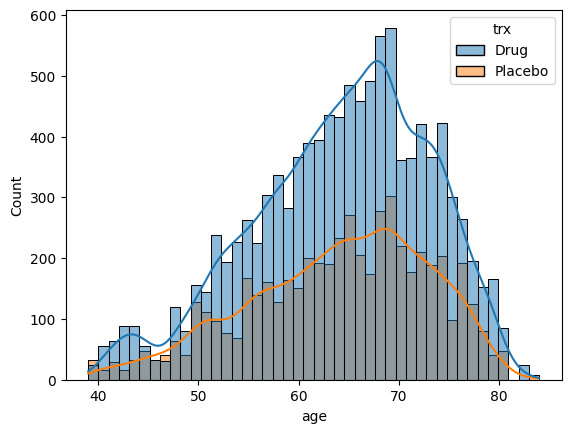

In [ ]:
# Filtrando os grupos
idade_drug = df[df["trx"] == "Drug"]["age"].dropna()
idade_placebo = df[df["trx"] == "Placebo"]["age"].dropna()

stat_d, p_norm_d = shapiro(idade_drug)
stat_p, p_norm_p = shapiro(idade_placebo)

print(f"P-valor normalidade Drug: {p_norm_d:.4f}")
print(f"P-valor normalidade Placebo: {p_norm_p:.4f}")

# Plotando os dados em um histograma
sns.histplot(data=df, x="age", hue="trx", kde=True)

In [ ]:
# Separando as idades por grupo
idade_drug = df[df['trx'] == 'Drug']['age'].dropna()
idade_placebo = df[df['trx'] == 'Placebo']['age'].dropna()

# Executando o teste U de Mann-Whitney
stat, age_group_effects_p_value = mannwhitneyu(idade_drug, idade_placebo)

print("-" * 35)
print(f"age_group_effects_p_value: {age_group_effects_p_value:.4f}")
print("-" * 35)

-----------------------------------
age_group_effects_p_value: 0.2570
-----------------------------------


<div class="alert alert-info">

- Como o valor de age_group_effects_p_value é superior a 0.05 (que corresponde a 5% de probabilidade da diferença ter acontecido por puro acaso), significa que não há diferença estatística significativa entre as idades dos grupos.

- Por fim, todos os dados indicam que o processo de separação dos pacientes foi bem feito e os grupos são comparáveis.
</div>

---

<div class='alert alert-success'>

<h1><b>Resumo Final</b></h1>

</div>

Este projeto realizou três testes de hipóteses sobre os dados do ensaio clínico da GlobalXYZ, com o objetivo de avaliar a segurança do fármaco em estudo.

| Teste | Variável | Conclusão |
|:------|:---------|:----------|
| Teste-Z de Proporções | `two_sample_p_value` | Sem diferença significativa na proporção de efeitos adversos |
| Qui-Quadrado de Independência | `num_effects_p_value` | `num_effects` é independente do grupo de tratamento |
| Mann-Whitney U (Idade) | `age_group_effects_p_value` | Sem diferença significativa de idade entre os grupos |

Os três testes convergem para a mesma conclusão: **o medicamento não apresenta perfil de segurança estatisticamente distinto do placebo**, e a randomização entre os grupos foi bem executada. Esses resultados são positivos do ponto de vista da segurança farmacológica.
